In [4]:
import requests
import pandas as pd

url = "https://api.binance.us/api/v3/klines"
params = {"symbol": "BTCUSDT", "interval": "1d", "limit": 1000}

resp = requests.get(url, params=params)
if resp.status_code == 200:
    data = resp.json()
    print(data[:2])  # first two rows
else:
    print("Error:", resp.status_code, resp.text)

[[1686787200000, '25132.59000000', '25722.99000000', '24817.35000000', '25595.96000000', '217.78144000', 1686873599999, '5492885.18751060', 29249, '121.24286000', '3062626.43419600', '0'], [1686873600000, '25605.96000000', '26452.16000000', '25289.67000000', '26354.99000000', '186.12735000', 1686959999999, '4820341.42912240', 17579, '94.67189000', '2452554.82925460', '0']]


In [5]:
cols = [
    "open_time","open","high","low","close","volume",
    "close_time","quote_asset_volume","num_trades",
    "taker_buy_base","taker_buy_quote","ignore"
]

df = pd.DataFrame(data, columns=cols)
df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
df["close_time"] = pd.to_datetime(df["close_time"], unit="ms")

for col in ["open","high","low","close","volume"]:
    df[col] = df[col].astype(float)

print(df.head())

   open_time      open      high       low     close     volume  \
0 2023-06-15  25132.59  25722.99  24817.35  25595.96  217.78144   
1 2023-06-16  25605.96  26452.16  25289.67  26354.99  186.12735   
2 2023-06-17  26354.98  26763.68  26078.69  26528.85  105.86557   
3 2023-06-18  26515.99  26707.24  26296.39  26349.44   95.21130   
4 2023-06-19  26349.44  26995.37  26272.97  26832.67  109.95144   

               close_time quote_asset_volume  num_trades taker_buy_base  \
0 2023-06-15 23:59:59.999   5492885.18751060       29249   121.24286000   
1 2023-06-16 23:59:59.999   4820341.42912240       17579    94.67189000   
2 2023-06-17 23:59:59.999   2796590.38796220       12644    53.61146000   
3 2023-06-18 23:59:59.999   2524106.81034050       11310    38.56863000   
4 2023-06-19 23:59:59.999   2928987.73148220       12502    55.93722000   

    taker_buy_quote ignore  
0  3062626.43419600      0  
1  2452554.82925460      0  
2  1417154.93192880      0  
3  1023871.94885380      0  
4

In [6]:
df["sma_fast"] = df["close"].rolling(20).mean()
df["sma_slow"] = df["close"].rolling(50).mean()
df["signal"] = (df["sma_fast"] > df["sma_slow"]).astype(int)

In [7]:
df["ret"] = df["close"].pct_change()
df["strategy"] = df["signal"].shift(1) * df["ret"]

cost = 0.001  # 0.1% fee
df["trade"] = df["signal"].diff().abs()
df["net_strategy"] = df["strategy"] - cost * df["trade"]

In [8]:
import numpy as np

def cagr(r): return (1+r).prod()**(365/len(r)) - 1
def sharpe(r): return np.sqrt(365) * r.mean() / r.std()
def max_dd(e): return (e/e.cummax()-1).min()

equity = (1+df["net_strategy"].fillna(0)).cumprod()
print("CAGR:", cagr(df["net_strategy"]))
print("Sharpe:", sharpe(df["net_strategy"]))
print("Max DD:", max_dd(equity))

CAGR: 0.2987177009760793
Sharpe: 0.9333178963447366
Max DD: -0.38563115166265005


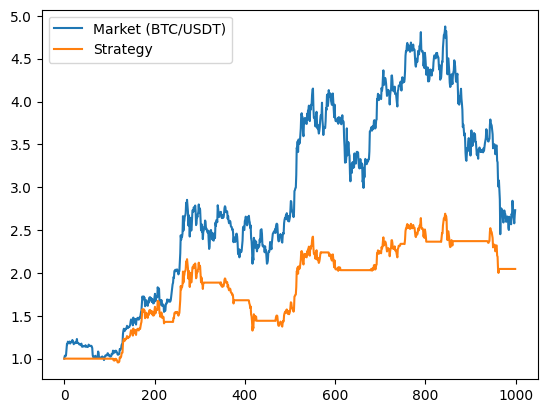

In [9]:
import matplotlib.pyplot as plt

equity_mkt = (1+df["ret"].fillna(0)).cumprod()
equity_strat = (1+df["net_strategy"].fillna(0)).cumprod()

plt.plot(equity_mkt, label="Market (BTC/USDT)")
plt.plot(equity_strat, label="Strategy")
plt.legend()
plt.show()